In [0]:
import matplotlib.pyplot as plt

flights_path = "/Volumes/mini_cap/default/airline_data/flights.csv"
bookings_path = "/Volumes/mini_cap/default/airline_data/bookings.csv"

In [0]:
df_flights = spark.read.option("header", "true").option("inferSchema", "true").csv(flights_path)
df_bookings = spark.read.option("header", "true").option("inferSchema", "true").csv(bookings_path)


In [0]:
df_joined = df_bookings.join(df_flights, on="flight_id", how="inner")

display(df_joined)

flight_id,booking_id,passenger_name,travel_class,ticket_price,booking_date,airline,from_city,to_city,duration,status
F101,B1001,Rahul Sharma,Economy,8500,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time
F101,B1002,Priya Reddy,Business,22000,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time
F102,B1003,Amit Kumar,Economy,9000,2026-06-02,Air India,Mumbai,Chennai,120,Delayed
F103,B1004,Sneha Patel,Premium Economy,15000,2026-06-02,Vistara,Bangalore,Hyderabad,90,On Time
F104,B1005,Farhan Ali,Economy,7500,2026-06-03,Indigo,Delhi,Mumbai,130,Cancelled
F105,B1006,Neha Singh,Business,25000,2026-06-03,Air India,Chennai,Bangalore,80,On Time
F106,B1007,Arjun Verma,Economy,10000,2026-06-04,Akasa,Pune,Delhi,150,Delayed
F107,B1008,Meera Nair,Premium Economy,17000,2026-06-04,Vistara,Hyderabad,Kolkata,160,On Time
F108,B1009,Kiran Rao,Economy,9500,2026-06-05,Indigo,Mumbai,Hyderabad,110,On Time
F109,B1010,Nisha Reddy,Business,28000,2026-06-05,Akasa,Delhi,Chennai,145,Delayed


In [0]:
from pyspark.sql.functions import sum as spark_sum
revenue_by_airline = (
    df_joined.groupBy("airline")
    .agg(spark_sum("ticket_price").alias("total_revenue"))
    .orderBy("total_revenue", ascending=False)
)
display(revenue_by_airline)

airline,total_revenue
Indigo,90000
Vistara,71500
Air India,68000
Akasa,62000


In [0]:
pdf_airline = revenue_by_airline.toPandas()

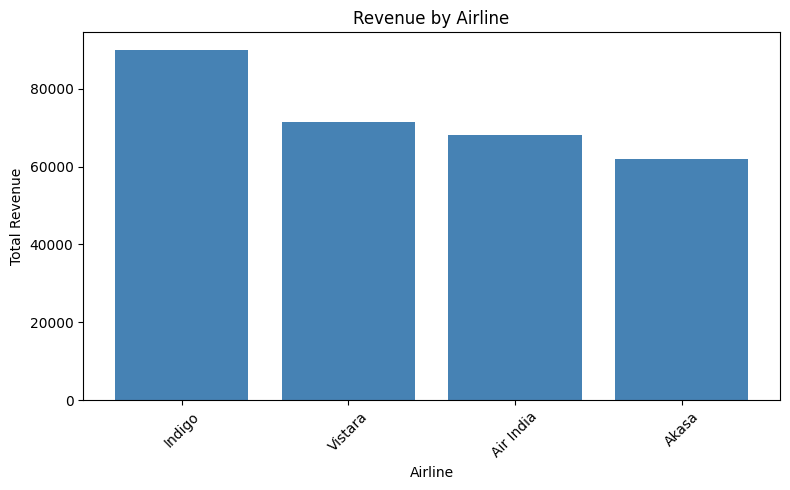

In [0]:
plt.figure(figsize=(8, 5))
plt.bar(pdf_airline["airline"], pdf_airline["total_revenue"], color="steelblue")
plt.title("Revenue by Airline")
plt.xlabel("Airline")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
revenue_by_class = (
    df_joined.groupBy("travel_class")
    .agg(spark_sum("ticket_price").alias("total_revenue"))
    .orderBy("total_revenue", ascending=False)
)

display(revenue_by_class)

pdf_class = revenue_by_class.toPandas()

travel_class,total_revenue
Business,122000
Economy,88000
Premium Economy,81500


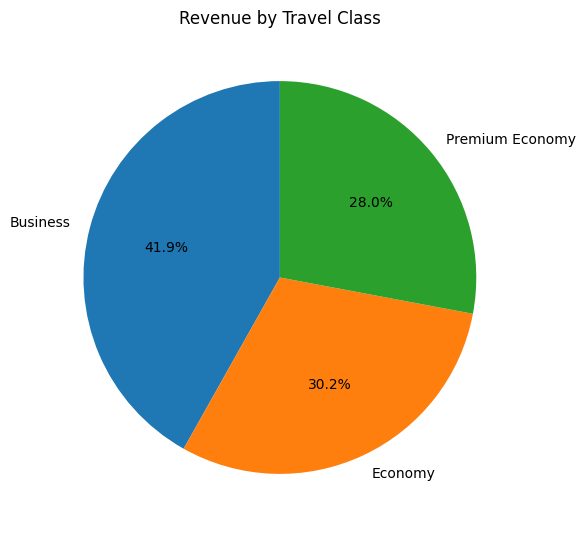

In [0]:
plt.figure(figsize=(6, 6))
plt.pie(
    pdf_class["total_revenue"],
    labels=pdf_class["travel_class"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue by Travel Class")
plt.tight_layout()
plt.show()

In [0]:
flights_by_status = (
    df_flights.groupBy("status")
    .count()
    .orderBy("count", ascending=False)
)

display(flights_by_status)

pdf_status = flights_by_status.toPandas()

status,count
On Time,9
Delayed,4
Cancelled,2


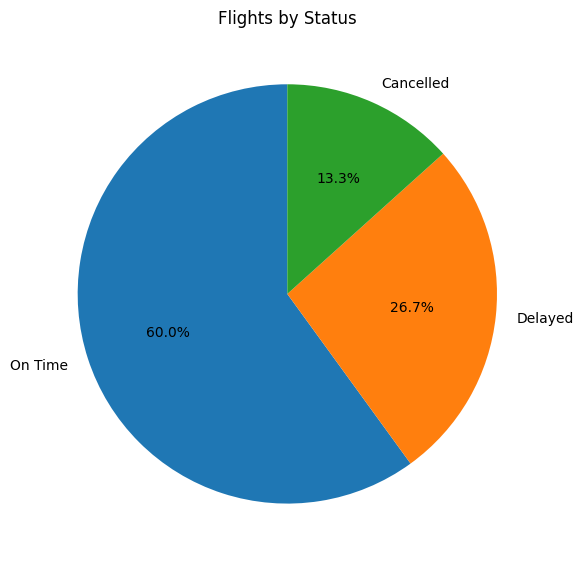

In [0]:
plt.figure(figsize=(6, 6))
plt.pie(
    pdf_status["count"],
    labels=pdf_status["status"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Flights by Status")
plt.tight_layout()
plt.show()

In [0]:
from pyspark.sql.functions import concat_ws
df_routes = df_flights.withColumn(
    "route", concat_ws(" -> ", df_flights["from_city"], df_flights["to_city"])
)

top_routes = (
    df_routes.groupBy("route")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
)

display(top_routes)

pdf_routes = top_routes.toPandas()

route,count
Hyderabad -> Delhi,1
Delhi -> Chennai,1
Bangalore -> Mumbai,1
Mumbai -> Chennai,1
Mumbai -> Hyderabad,1
Kolkata -> Bangalore,1
Pune -> Delhi,1
Delhi -> Mumbai,1
Delhi -> Hyderabad,1
Hyderabad -> Goa,1


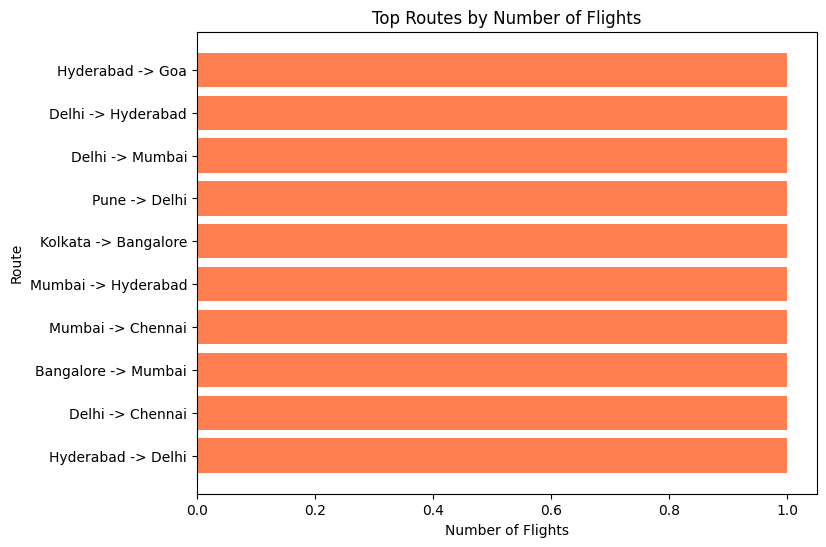

In [0]:
plt.figure(figsize=(8, 6))
plt.barh(pdf_routes["route"], pdf_routes["count"], color="coral")
plt.title("Top Routes by Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

In [0]:
pdf_prices = df_bookings.select("booking_date", "ticket_price").toPandas()

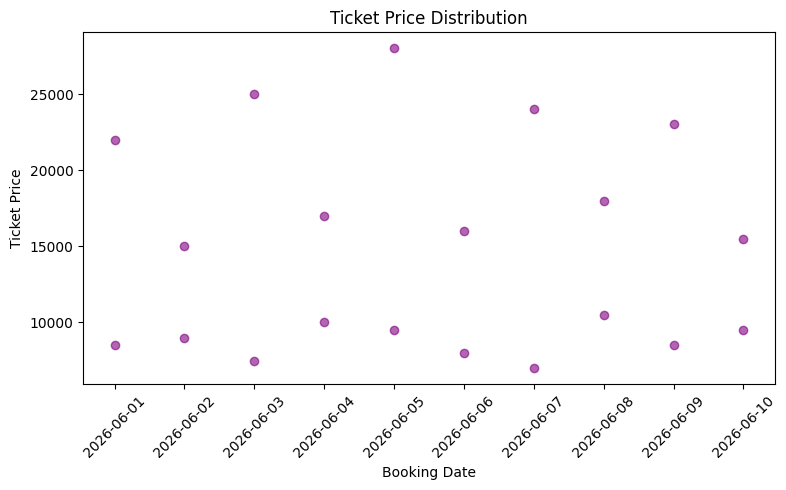

In [0]:
plt.figure(figsize=(8, 5))
plt.scatter(pdf_prices["booking_date"], pdf_prices["ticket_price"], color="purple", alpha=0.6)
plt.title("Ticket Price Distribution")
plt.xlabel("Booking Date")
plt.ylabel("Ticket Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()